# 03 FedSTO Guarded 8 Hour Reproduction

This notebook keeps the paper-scale FedSTO data interface and EfficientTeacher YOLOv5L SSOD trainer stack, but uses the same shortened schedule as the DQA notebook so a clean run lands around 8 hours instead of the full multi-day 50/100/150 paper schedule. It still targets the BDD100K non-IID weather setup used in the paper: cloudy server labels and overcast/rainy/snowy unlabeled clients.

In [1]:
print("hello")

hello


In [ ]:
from pathlib import Path
import json
import subprocess
import sys
from typing import Optional


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    markers = (
        "setup_fedsto_exact_reproduction.py",
        "run_fedsto_efficientteacher_exact.py",
        "03_fedsto_exact_reproduction.ipynb",
    )
    candidate_dirs = []
    for base in (start, *start.parents):
        candidate_dirs.extend([
            base,
            base / "navigating_data_heterogeneity",
            base / "Object_Detection" / "navigating_data_heterogeneity",
            base / "masters_research" / "navigating_data_heterogeneity",
        ])
    for candidate in candidate_dirs:
        if all((candidate / marker).exists() for marker in markers[:2]) or any((candidate / marker).exists() for marker in markers):
            return candidate.resolve()
    for pattern in (
        "*/setup_fedsto_exact_reproduction.py",
        "*/*/setup_fedsto_exact_reproduction.py",
    ):
        matches = list(start.glob(pattern))
        if matches:
            return matches[0].parent.resolve()
    return start


PROJECT_ROOT = find_project_root()
SETUP_SCRIPT = PROJECT_ROOT / "setup_fedsto_exact_reproduction.py"
RUN_SCRIPT = PROJECT_ROOT / "run_fedsto_efficientteacher_exact.py"
WORK_ROOT = PROJECT_ROOT / "efficientteacher_fedsto_guarded_8h"

missing = [path for path in (SETUP_SCRIPT, RUN_SCRIPT) if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required scripts:\n" + "\n".join(str(path) for path in missing))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SETUP_SCRIPT:", SETUP_SCRIPT)
print("RUN_SCRIPT:", RUN_SCRIPT)
print("WORK_ROOT:", WORK_ROOT)

## 1. Repair/Rebuild Paper-Scale Data

Run this if EfficientTeacher reports many corrupt images or no labels. It rebuilds `data_paper20k` from the local BDD100K raw dataset and removes stale EfficientTeacher cache files. Use `COPY_IMAGES=True` for Docker or moved workspaces.


In [3]:
COPY_IMAGES = True

cmd = [sys.executable, str(PROJECT_ROOT / "prepare_bdd100k_paper20k.py")]
if COPY_IMAGES:
    cmd.append("--copy-images")
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

for cache_path in (PROJECT_ROOT / "efficientteacher_fedsto" / "data_lists").glob("*.cache"):
    cache_path.unlink()
    print("removed stale cache:", cache_path)


{
  "server_weather": "partly cloudy",
  "client_weathers": [
    "overcast",
    "rainy",
    "snowy"
  ],
  "server": [
    {
      "split": "train",
      "num_images": 4881,
      "num_boxes": 97123,
      "class_counts": {
        "traffic sign": 18325,
        "person": 6370,
        "car": 55752,
        "bus": 1112,
        "traffic light": 11415,
        "bike": 488,
        "truck": 2993,
        "motor": 270,
        "rider": 376,
        "train": 22
      }
    },
    {
      "split": "val",
      "num_images": 738,
      "num_boxes": 14937,
      "class_counts": {
        "car": 8622,
        "person": 1052,
        "traffic light": 1619,
        "traffic sign": 2845,
        "truck": 467,
        "bus": 151,
        "motor": 65,
        "bike": 70,
        "rider": 44,
        "train": 2
      }
    }
  ],
  "clients": [
    {
      "client_id": 0,
      "weather": "overcast",
      "num_images": 5000
    },
    {
      "client_id": 1,
      "weather": "rainy",
      "num

## 2. Build Paper-Scale Data Interface

This creates EfficientTeacher-compatible list files and YAML configs from the BDD100K paper-scale split already prepared in `data_paper20k`.

In [ ]:
subprocess.run([
    sys.executable,
    str(RUN_SCRIPT),
    "--setup-only",
    "--workspace-root",
    str(WORK_ROOT),
], cwd=PROJECT_ROOT, check=True)
manifest = json.loads((WORK_ROOT / "manifest.json").read_text())
manifest

## 3. Confirm Paper Conditions

In [5]:
summary = {
    "server_train_images": manifest["server"]["train_images"],
    "server_val_images": manifest["server"]["val_images"],
    "client_images": {f"client_{c['id']}_{c['weather']}": c["images"] for c in manifest["clients"]},
    "classes": manifest["classes"],
    "schedule": manifest["paper_schedule"],
    "official_ssfod_sha": manifest["official_ssfod_sha"],
    "efficientteacher_sha": manifest["efficientteacher_sha"],
}
summary

{'server_train_images': 4881,
 'server_val_images': 738,
 'client_images': {'client_0_overcast': 5000,
  'client_1_rainy': 5000,
  'client_2_snowy': 5000},
 'classes': ['person',
  'rider',
  'car',
  'bus',
  'truck',
  'bike',
  'motor',
  'traffic light',
  'traffic sign',
  'train'],
 'schedule': {'warmup_epochs': 50,
  'phase1_rounds': 100,
  'phase2_rounds': 150,
  'local_epochs': 1},
 'official_ssfod_sha': '6906766f40f5d86639b81dc77f048edeea16c2e4',
 'efficientteacher_sha': '6906766f40f5d86639b81dc77f048edeea16c2e4'}

## 4. EfficientTeacher Runtime Dependency Check

Run this before starting real training. Dry-run only checks command/config generation; this cell checks imports used by EfficientTeacher.


In [6]:
import importlib.util

required = {
    "yaml": "PyYAML",
    "cv2": "opencv-python",
    "thop": "thop",
    "tensorboard": "tensorboard",
    "sklearn": "scikit-learn",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]

pkg_resources_shim = PROJECT_ROOT / "vendor" / "efficientteacher" / "pkg_resources.py"
if importlib.util.find_spec("pkg_resources") is None and not pkg_resources_shim.exists():
    missing.append("setuptools<81")

if missing:
    print("Missing packages:", missing)
    print("Install in this kernel/environment, then rerun this cell:")
    print(f"{sys.executable} -m pip install " + " ".join(missing))
    raise ModuleNotFoundError("Missing EfficientTeacher dependencies: " + ", ".join(missing))
else:
    print("EfficientTeacher runtime dependency check OK")
    if pkg_resources_shim.exists():
        print("Using vendor pkg_resources shim:", pkg_resources_shim)


EfficientTeacher runtime dependency check OK
Using vendor pkg_resources shim: /app/Object_Detection/navigating_data_heterogeneity/vendor/efficientteacher/pkg_resources.py


## 5. Dry-Run Command Check

This verifies the runner and runtime config generation without starting training.

In [ ]:
subprocess.run([
    sys.executable, str(RUN_SCRIPT),
    "--workspace-root", str(WORK_ROOT),
    "--dry-run",
    "--warmup-epochs", "1",
    "--phase1-rounds", "1",
    "--phase2-rounds", "1",
], cwd=PROJECT_ROOT, check=True)

## 6. Guarded 8 Hour Reproduction Run

This production path keeps the same paper-scale data split and FedSTO phase structure, but shortens the schedule to 15 warm-up epochs, 14 phase-1 rounds, and 27 phase-2 rounds so it lands near the same 8-hour turnaround as the DQA notebook on the same hardware.

The measured full FedSTO log used by the DQA notebook recorded 50 warm-up epochs at about 0.982 hours, phase-1 rounds at about 10.46 minutes each, and phase-2 rounds at about 11.17 minutes each. That makes this 15/14/27 profile roughly 7.8 hours before small environment-dependent overhead. The run also uses a dedicated workspace, so it does not collide with any full 50/100/150 artifacts.

In [ ]:
import re
import socket
import time
from collections import deque

RUN_FULL_REPRODUCTION = True
ALLOW_CPU_TRAINING = False
FORCE_RESTART = False
FORCE_WARMUP = False
FORCE_RETRAIN = False

WARMUP_EPOCHS = 15
PHASE1_ROUNDS = 14
PHASE2_ROUNDS = 27
BATCH_SIZE = "64"  # 2 GPUs x 32 images/GPU.
DATALOADER_WORKERS = "0"  # Keep 0 when Docker /dev/shm is small.
REQUESTED_GPUS = 2
STATUS_EVERY_SECONDS = 60

try:
    import torch

    AVAILABLE_CUDA_GPUS = torch.cuda.device_count()
except Exception as exc:
    AVAILABLE_CUDA_GPUS = 0
    print("Could not inspect CUDA devices:", exc)

NUM_GPUS = str(min(REQUESTED_GPUS, AVAILABLE_CUDA_GPUS) if AVAILABLE_CUDA_GPUS else 1)
if int(NUM_GPUS) != REQUESTED_GPUS:
    print(
        f"Requested {REQUESTED_GPUS} GPUs, but {AVAILABLE_CUDA_GPUS} CUDA device(s) are visible. "
        f"Using NUM_GPUS={NUM_GPUS} to avoid DDP launch failure."
    )


def find_free_port(preferred: int) -> int:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        try:
            sock.bind(("127.0.0.1", preferred))
            return preferred
        except OSError:
            pass
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.bind(("127.0.0.1", 0))
        return int(sock.getsockname()[1])


MASTER_PORT = str(find_free_port(29513))
RUN_LOG_PATH = WORK_ROOT / "guarded_8h_reproduction_latest.log"

# Guarded 8-hour FedSTO profile derived from the same timing baseline used by the DQA notebook.
# This runner resumes from history.json and reuses completed per-client runs inside the dedicated workspace.

cmd = [
    sys.executable, "-u", str(RUN_SCRIPT),
    "--workspace-root", str(WORK_ROOT),
    "--warmup-epochs", str(WARMUP_EPOCHS),
    "--phase1-rounds", str(PHASE1_ROUNDS),
    "--phase2-rounds", str(PHASE2_ROUNDS),
    "--batch-size", BATCH_SIZE,
    "--workers", DATALOADER_WORKERS,
    "--gpus", NUM_GPUS,
    "--master-port", MASTER_PORT,
]
if FORCE_RESTART:
    cmd.append("--force-restart")
if FORCE_WARMUP:
    cmd.append("--force-warmup")
if FORCE_RETRAIN:
    cmd.append("--force-retrain")

IMPORTANT_OUTPUT = re.compile(
    r"(Resuming after|No completed federated rounds|Current global checkpoint|"
    r"Reusing completed (warm-up|client run|server run|global checkpoint)|"
    r"Recovered phase|Completed phase|All requested federated rounds|"
    r"Dry run complete|Downloading|Traceback|RuntimeError|Exception|Error|out of memory|CUDA error)",
    re.IGNORECASE,
)


def compact_line(line: str, limit: int = 240) -> str:
    text = line.replace("\r", "").strip()
    return text if len(text) <= limit else text[: limit - 3] + "..."


if RUN_FULL_REPRODUCTION and AVAILABLE_CUDA_GPUS < 1 and not ALLOW_CPU_TRAINING:
    print(
        "No CUDA GPU is visible, so the guarded FedSTO run was not started. "
        "Use a GPU runtime, or set ALLOW_CPU_TRAINING = True for a tiny debug run."
    )
elif RUN_FULL_REPRODUCTION:
    log_path = RUN_LOG_PATH
    log_path.parent.mkdir(parents=True, exist_ok=True)
    print({
        "workspace": str(WORK_ROOT),
        "warmup_epochs": WARMUP_EPOCHS,
        "phase1_rounds": PHASE1_ROUNDS,
        "phase2_rounds": PHASE2_ROUNDS,
        "requested_gpus": REQUESTED_GPUS,
        "available_cuda_gpus": AVAILABLE_CUDA_GPUS,
        "gpus": int(NUM_GPUS),
        "batch_size": int(BATCH_SIZE),
        "workers": int(DATALOADER_WORKERS),
        "master_port": int(MASTER_PORT),
    })
    print("Running:", " ".join(cmd))
    print("Run log:", log_path)
    recent = deque(maxlen=20)
    last_status = time.monotonic()
    with log_path.open("a", encoding="utf-8", buffering=1) as log_file:
        log_file.write("\n\n===== FedSTO guarded 8-hour reproduction resumed =====\n")
        log_file.write("Running: " + " ".join(cmd) + "\n")
        process = subprocess.Popen(
            cmd,
            cwd=PROJECT_ROOT,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert process.stdout is not None
        for line in process.stdout:
            log_file.write(line)
            recent.append(line)
            if IMPORTANT_OUTPUT.search(line):
                print(compact_line(line))
                last_status = time.monotonic()
            elif time.monotonic() - last_status >= STATUS_EVERY_SECONDS:
                print(f"[running] full log is still updating: {log_path}")
                last_status = time.monotonic()
        return_code = process.wait()
    if return_code != 0:
        print("Last captured lines:")
        for line in recent:
            text = compact_line(line)
            if text:
                print(text)
        raise subprocess.CalledProcessError(return_code, cmd)
    print("FedSTO guarded 8-hour reproduction command finished successfully.")
else:
    print("Set RUN_FULL_REPRODUCTION = True to start or resume the guarded 8-hour FedSTO reproduction run.")

## 7. Inspect Outputs

In [ ]:
history_path = WORK_ROOT / "history.json"
if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
else:
    history = []

schedule = manifest.get("paper_schedule", {}) if "manifest" in globals() else {}
warmup_epochs = int(globals().get("WARMUP_EPOCHS", schedule.get("warmup_epochs", 50)))
phase1_rounds = int(globals().get("PHASE1_ROUNDS", schedule.get("phase1_rounds", 100)))
phase2_rounds = int(globals().get("PHASE2_ROUNDS", schedule.get("phase2_rounds", 150)))
expected_total = phase1_rounds + phase2_rounds
completed = {(int(entry["phase"]), int(entry["round"])) for entry in history if "phase" in entry and "round" in entry}

print(f"configured schedule: warmup={warmup_epochs}, phase1={phase1_rounds}, phase2={phase2_rounds}")
print(f"completed history rounds: {len(history)} / {expected_total}")
if history:
    print("latest history entry:", history[-1])
else:
    print("history.json has no completed federated rounds yet.")

next_round = None
for phase, rounds in [(1, phase1_rounds), (2, phase2_rounds)]:
    for round_idx in range(1, rounds + 1):
        if (phase, round_idx) not in completed:
            next_round = (phase, round_idx)
            break
    if next_round:
        break

if next_round is None:
    print("next runner step: all requested rounds are complete")
else:
    phase, round_idx = next_round
    print(f"next runner step: phase {phase} round {round_idx}")
    for client in manifest.get("clients", []):
        run_name = f"phase{phase}_round{round_idx:03d}_client{client['id']}_{client['weather']}"
        ckpt = WORK_ROOT / "runs" / run_name / "weights" / "last.pt"
        status = "done" if ckpt.exists() and ckpt.stat().st_size >= 1024 * 1024 else "missing"
        print(f"  {run_name}: {status}")
    server_name = f"phase{phase}_round{round_idx:03d}_server"
    server_ckpt = WORK_ROOT / "runs" / server_name / "weights" / "last.pt"
    global_ckpt = WORK_ROOT / "global_checkpoints" / f"phase{phase}_round{round_idx:03d}_global.pt"
    print(f"  {server_name}: {'done' if server_ckpt.exists() and server_ckpt.stat().st_size >= 1024 * 1024 else 'missing'}")
    print(f"  global checkpoint: {'done' if global_ckpt.exists() and global_ckpt.stat().st_size >= 1024 * 1024 else 'missing'}")

print("runs:", WORK_ROOT / "runs")
print("global checkpoints:", WORK_ROOT / "global_checkpoints")
print("client EMA states:", WORK_ROOT / "client_states")
print("run log:", globals().get("RUN_LOG_PATH", WORK_ROOT / "guarded_8h_reproduction_latest.log"))

## 8. Paper-Grade Validation Suite

The cells below turn the reproduction run into auditable evidence for a paper: split integrity, YOLO label validity, training accuracy, per-round/client coverage, checkpoint health, protocol/config compliance, log triage, and optional explicit final validation.

They are safe to run after setup, dry-run, partial training, or the guarded 15/14/27 schedule. Missing artifacts are reported as incomplete evidence instead of being silently ignored. All reusable tables and figures are written under the current workspace's `validation_reports/` directory.

In [ ]:
# Validation setup and shared helpers.
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timezone
import json
import math
import re
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ModuleNotFoundError:
    yaml = None


def _find_project_root_for_validation(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    markers = ("setup_fedsto_exact_reproduction.py", "run_fedsto_efficientteacher_exact.py")
    candidate_dirs = []
    for base in (start, *start.parents):
        candidate_dirs.extend([
            base,
            base / "navigating_data_heterogeneity",
            base / "Object_Detection" / "navigating_data_heterogeneity",
            base / "masters_research" / "navigating_data_heterogeneity",
        ])
    for candidate in candidate_dirs:
        if all((candidate / marker).exists() for marker in markers):
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the FedSTO reproduction project root.")


if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = _find_project_root_for_validation()
if "WORK_ROOT" not in globals():
    WORK_ROOT = PROJECT_ROOT / "efficientteacher_fedsto_guarded_8h"
if "SETUP_SCRIPT" not in globals():
    SETUP_SCRIPT = PROJECT_ROOT / "setup_fedsto_exact_reproduction.py"
if "RUN_SCRIPT" not in globals():
    RUN_SCRIPT = PROJECT_ROOT / "run_fedsto_efficientteacher_exact.py"

REPORT_ROOT = WORK_ROOT / "validation_reports"
FIG_ROOT = REPORT_ROOT / "figures"
TABLE_ROOT = REPORT_ROOT / "tables"
for directory in (REPORT_ROOT, FIG_ROOT, TABLE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

manifest_path = WORK_ROOT / "manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
elif "manifest" not in globals():
    raise FileNotFoundError(f"Missing manifest: {manifest_path}. Run the setup cell first.")

CLASS_NAMES = list(manifest.get("classes", []))
NC = len(CLASS_NAMES)
PAPER_SCHEDULE = manifest.get("paper_schedule", {})
ACTIVE_SCHEDULE = {
    "warmup_epochs": int(globals().get("WARMUP_EPOCHS", PAPER_SCHEDULE.get("warmup_epochs", 50))),
    "phase1_rounds": int(globals().get("PHASE1_ROUNDS", PAPER_SCHEDULE.get("phase1_rounds", 100))),
    "phase2_rounds": int(globals().get("PHASE2_ROUNDS", PAPER_SCHEDULE.get("phase2_rounds", 150))),
    "local_epochs": int(PAPER_SCHEDULE.get("local_epochs", 1)),
}
EXPECTED_CLIENT_COUNT = len(manifest.get("clients", []))


def read_lines(path: Path) -> list[str]:
    if not path.exists():
        return []
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def rel(path: Path | str) -> str:
    path = Path(path)
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT.resolve()))
    except Exception:
        return str(path)


def save_table(df: pd.DataFrame, name: str, *, index: bool = False) -> Path:
    path = TABLE_ROOT / name
    df.to_csv(path, index=index)
    print(f"saved table: {rel(path)}")
    return path


def display_table(df: pd.DataFrame, rows: int = 20) -> None:
    if df.empty:
        print("empty table")
        return
    try:
        display(df.head(rows))
    except NameError:
        print(df.head(rows).to_string(index=False))


def numeric_or_nan(value):
    try:
        value = float(value)
    except Exception:
        return np.nan
    return value if math.isfinite(value) else np.nan


try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

print("PROJECT_ROOT:", PROJECT_ROOT)
print("WORK_ROOT:", WORK_ROOT)
print("REPORT_ROOT:", REPORT_ROOT)
print("classes:", NC, CLASS_NAMES)
print("paper schedule:", PAPER_SCHEDULE)
print("active schedule:", ACTIVE_SCHEDULE)

In [11]:
# Dataset, split, and YOLO label integrity audit.
# This is the first table to include in the paper appendix: it proves exactly what data was evaluated.

CHECK_IMAGE_READABILITY = False  # Set True for a slower PIL verify pass over the listed images.
MAX_READABILITY_CHECKS_PER_SPLIT = 200


def label_path_for_image(image_path: Path) -> Path | None:
    parts = list(image_path.parts)
    if "images" not in parts:
        return None
    parts[parts.index("images")] = "labels"
    return Path(*parts).with_suffix(".txt")


def audit_yolo_labels(split_name: str, image_paths: list[Path], require_labels: bool) -> tuple[dict, list[dict]]:
    label_counter = Counter()
    errors = []
    missing_labels = 0
    empty_label_files = 0
    total_boxes = 0

    for image_path in image_paths:
        label_path = label_path_for_image(image_path)
        if label_path is None:
            errors.append({"split": split_name, "image": str(image_path), "label": "", "error": "image path has no images directory"})
            continue
        if not label_path.exists():
            if require_labels:
                missing_labels += 1
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "error": "missing label file"})
            continue

        lines = label_path.read_text(encoding="utf-8").splitlines()
        nonempty = [line.strip() for line in lines if line.strip()]
        if not nonempty:
            empty_label_files += 1
        for line_number, line in enumerate(nonempty, start=1):
            parts = line.split()
            if len(parts) < 5:
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "line": line_number, "error": "fewer than 5 YOLO fields"})
                continue
            try:
                cls = int(float(parts[0]))
                coords = [float(x) for x in parts[1:5]]
            except ValueError:
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "line": line_number, "error": "non-numeric YOLO fields"})
                continue
            x, y, w, h = coords
            total_boxes += 1
            label_counter[cls] += 1
            if not (0 <= cls < NC):
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "line": line_number, "error": f"class id out of range: {cls}"})
            if not all(math.isfinite(v) for v in coords):
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "line": line_number, "error": "non-finite box coordinate"})
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                errors.append({"split": split_name, "image": str(image_path), "label": str(label_path), "line": line_number, "error": f"box outside normalized YOLO range: {coords}"})

    audit = {
        "split": split_name,
        "require_labels": require_labels,
        "images": len(image_paths),
        "missing_labels": missing_labels,
        "empty_label_files": empty_label_files,
        "boxes": total_boxes,
        "label_errors": len(errors),
    }
    for class_id, class_name in enumerate(CLASS_NAMES):
        audit[f"boxes_{class_name}"] = label_counter.get(class_id, 0)
    return audit, errors


def verify_images(split_name: str, image_paths: list[Path]) -> list[dict]:
    if not CHECK_IMAGE_READABILITY:
        return []
    try:
        from PIL import Image
    except ModuleNotFoundError:
        print("PIL is not installed; skipping image readability checks.")
        return []
    problems = []
    for image_path in image_paths[:MAX_READABILITY_CHECKS_PER_SPLIT]:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception as exc:
            problems.append({"split": split_name, "image": str(image_path), "error": repr(exc)})
    return problems


list_specs = [
    ("server_train", Path(manifest["server"]["train_list"]), True),
    ("server_val", Path(manifest["server"]["val_list"]), True),
]
for client in manifest.get("clients", []):
    list_specs.append((f"client_{client['id']}_{client['weather']}", Path(client["list"]), False))

split_rows = []
label_rows = []
label_errors = []
image_errors = []
paths_by_split: dict[str, list[Path]] = {}

for split_name, list_path, require_labels in list_specs:
    lines = read_lines(list_path)
    image_paths = [Path(line) for line in lines]
    paths_by_split[split_name] = image_paths
    existing_images = [path for path in image_paths if path.exists()]
    missing_images = [path for path in image_paths if not path.exists()]
    audit, errors = audit_yolo_labels(split_name, existing_images, require_labels=require_labels)
    label_errors.extend(errors)
    image_errors.extend(verify_images(split_name, existing_images))
    split_rows.append({
        "split": split_name,
        "list_path": str(list_path),
        "listed_images": len(image_paths),
        "existing_images": len(existing_images),
        "missing_images": len(missing_images),
        "requires_labels": require_labels,
        "missing_labels": audit["missing_labels"],
        "empty_label_files": audit["empty_label_files"],
        "boxes": audit["boxes"],
        "label_errors": audit["label_errors"],
        "readability_errors": sum(1 for problem in image_errors if problem["split"] == split_name),
    })
    for class_id, class_name in enumerate(CLASS_NAMES):
        label_rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "boxes": audit.get(f"boxes_{class_name}", 0),
        })

overlap_rows = []
split_names = list(paths_by_split)
for i, left in enumerate(split_names):
    left_paths = {str(path.resolve()) for path in paths_by_split[left] if path.exists()}
    left_names = {path.name for path in paths_by_split[left]}
    for right in split_names[i + 1:]:
        right_paths = {str(path.resolve()) for path in paths_by_split[right] if path.exists()}
        right_names = {path.name for path in paths_by_split[right]}
        overlap_rows.append({
            "left_split": left,
            "right_split": right,
            "same_path_overlap": len(left_paths & right_paths),
            "same_filename_overlap": len(left_names & right_names),
        })

split_audit = pd.DataFrame(split_rows)
class_distribution = pd.DataFrame(label_rows)
split_overlap = pd.DataFrame(overlap_rows)
label_error_table = pd.DataFrame(label_errors)
image_error_table = pd.DataFrame(image_errors)

save_table(split_audit, "dataset_split_audit.csv")
save_table(class_distribution, "dataset_class_distribution.csv")
save_table(split_overlap, "dataset_split_overlap.csv")
if not label_error_table.empty:
    save_table(label_error_table.head(1000), "dataset_label_errors_first1000.csv")
if not image_error_table.empty:
    save_table(image_error_table, "dataset_image_readability_errors.csv")

print("Split audit")
display_table(split_audit, rows=20)
print("Class distribution for labeled server splits")
display_table(class_distribution[class_distribution["split"].isin(["server_train", "server_val"])], rows=30)
print("Potential leakage/duplicate overlap")
display_table(split_overlap, rows=30)

saved table: efficientteacher_fedsto/validation_reports/tables/dataset_split_audit.csv
saved table: efficientteacher_fedsto/validation_reports/tables/dataset_class_distribution.csv
saved table: efficientteacher_fedsto/validation_reports/tables/dataset_split_overlap.csv
Split audit


,split,list_path,listed_images,existing_images,missing_images,requires_labels,missing_labels,empty_label_files,boxes,label_errors,readability_errors
0,server_train,/app/Object_Detection/navigating_data_heteroge...,4881,4881,0,True,0,0,97123,0,0
1,server_val,/app/Object_Detection/navigating_data_heteroge...,738,738,0,True,0,0,14937,0,0
2,client_0_overcast,/app/Object_Detection/navigating_data_heteroge...,5000,5000,0,False,0,0,0,0,0
3,client_1_rainy,/app/Object_Detection/navigating_data_heteroge...,5000,5000,0,False,0,0,0,0,0
4,client_2_snowy,/app/Object_Detection/navigating_data_heteroge...,5000,5000,0,False,0,0,0,0,0


Class distribution for labeled server splits


,split,class_id,class_name,boxes
0,server_train,0,person,6370
1,server_train,1,rider,376
2,server_train,2,car,55752
3,server_train,3,bus,1112
4,server_train,4,truck,2993
5,server_train,5,bike,488
6,server_train,6,motor,270
7,server_train,7,traffic light,11415
8,server_train,8,traffic sign,18325
9,server_train,9,train,22


Potential leakage/duplicate overlap


,left_split,right_split,same_path_overlap,same_filename_overlap
0,server_train,server_val,0,0
1,server_train,client_0_overcast,0,0
2,server_train,client_1_rainy,0,0
3,server_train,client_2_snowy,0,0
4,server_val,client_0_overcast,0,0
5,server_val,client_1_rainy,0,0
6,server_val,client_2_snowy,0,0
7,client_0_overcast,client_1_rainy,0,0
8,client_0_overcast,client_2_snowy,0,0
9,client_1_rainy,client_2_snowy,0,0


In [12]:
# Ingest EfficientTeacher results.csv files and build accuracy tables.
# These metrics are validation-set metrics emitted by EfficientTeacher during each training run.

METRIC_COLUMNS = [
    "metrics/precision",
    "metrics/recall",
    "metrics/mAP_0.5",
    "metrics/mAP_0.5:0.95",
    "train/box_loss",
    "train/obj_loss",
    "train/cls_loss",
    "val/box_loss",
    "val/obj_loss",
    "val/cls_loss",
]


def parse_run_metadata(run_name: str) -> dict:
    if run_name == "runtime_server_warmup" or "warmup" in run_name:
        return {"phase": 0, "round": 0, "role": "warmup", "client_id": np.nan, "weather": "server_cloudy"}
    client_match = re.match(r"phase(?P<phase>[12])_round(?P<round>\d+)_client(?P<client_id>\d+)_(?P<weather>.+)$", run_name)
    if client_match:
        out = client_match.groupdict()
        return {"phase": int(out["phase"]), "round": int(out["round"]), "role": "client", "client_id": int(out["client_id"]), "weather": out["weather"]}
    server_match = re.match(r"phase(?P<phase>[12])_round(?P<round>\d+)_server$", run_name)
    if server_match:
        out = server_match.groupdict()
        return {"phase": int(out["phase"]), "round": int(out["round"]), "role": "server", "client_id": np.nan, "weather": "server_cloudy"}
    return {"phase": np.nan, "round": np.nan, "role": "unknown", "client_id": np.nan, "weather": "unknown"}


def load_results_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [column.strip() for column in df.columns]
    df.insert(0, "row_index", np.arange(len(df)))
    run_name = path.parent.name
    metadata = parse_run_metadata(run_name)
    df.insert(0, "run_name", run_name)
    df.insert(1, "run_dir", str(path.parent))
    df.insert(2, "source_csv", str(path))
    for key, value in metadata.items():
        df[key] = value
    for column in df.columns:
        if column not in {"run_name", "run_dir", "source_csv", "role", "weather"}:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


result_files = sorted((WORK_ROOT / "runs").glob("*/results.csv"))
metric_frames = []
bad_result_files = []
for result_file in result_files:
    try:
        metric_frames.append(load_results_csv(result_file))
    except Exception as exc:
        bad_result_files.append({"path": str(result_file), "error": repr(exc)})

if metric_frames:
    all_metrics = pd.concat(metric_frames, ignore_index=True, sort=False)
else:
    all_metrics = pd.DataFrame()

if bad_result_files:
    bad_results = pd.DataFrame(bad_result_files)
    save_table(bad_results, "training_results_parse_errors.csv")
    display_table(bad_results)

if all_metrics.empty:
    print("No EfficientTeacher results.csv files found yet under", WORK_ROOT / "runs")
else:
    save_table(all_metrics, "training_metrics_all_epochs.csv")
    summary_rows = []
    for run_name, group in all_metrics.groupby("run_name", sort=False):
        group = group.sort_values("row_index")
        final = group.iloc[-1]
        score = group["metrics/mAP_0.5:0.95"] if "metrics/mAP_0.5:0.95" in group else pd.Series(dtype=float)
        if score.notna().any():
            best = group.loc[score.idxmax()]
            best_basis = "metrics/mAP_0.5:0.95"
        elif "metrics/mAP_0.5" in group and group["metrics/mAP_0.5"].notna().any():
            best = group.loc[group["metrics/mAP_0.5"].idxmax()]
            best_basis = "metrics/mAP_0.5"
        else:
            best = final
            best_basis = "final_row"
        record = {
            "run_name": run_name,
            "run_dir": final.get("run_dir"),
            "phase": final.get("phase"),
            "round": final.get("round"),
            "role": final.get("role"),
            "client_id": final.get("client_id"),
            "weather": final.get("weather"),
            "n_logged_rows": len(group),
            "final_epoch": final.get("epoch"),
            "best_epoch": best.get("epoch"),
            "best_basis": best_basis,
        }
        for metric in METRIC_COLUMNS:
            if metric in group.columns:
                record[f"final_{metric}"] = final.get(metric)
                record[f"best_{metric}"] = best.get(metric)
        summary_rows.append(record)

    run_summary = pd.DataFrame(summary_rows)
    save_table(run_summary, "training_run_summary.csv")

    expected_clients = {int(client["id"]) for client in manifest.get("clients", [])}
    coverage_rows = []
    parsed_rounds = run_summary[run_summary["phase"].isin([1, 2])].copy()
    for (phase, round_idx), group in parsed_rounds.groupby(["phase", "round"], dropna=True):
        clients_seen = sorted(int(x) for x in group.loc[group["role"] == "client", "client_id"].dropna().unique())
        has_server = bool((group["role"] == "server").any())
        coverage_rows.append({
            "phase": int(phase),
            "round": int(round_idx),
            "client_runs": len(clients_seen),
            "clients_seen": ",".join(map(str, clients_seen)),
            "missing_clients": ",".join(map(str, sorted(expected_clients - set(clients_seen)))),
            "has_server_run": has_server,
            "complete_round_outputs": has_server and set(clients_seen) == expected_clients,
        })
    round_coverage = pd.DataFrame(coverage_rows).sort_values(["phase", "round"]) if coverage_rows else pd.DataFrame()
    save_table(round_coverage, "training_round_coverage.csv")

    print("Best/final accuracy by run")
    display_cols = [
        "run_name", "phase", "round", "role", "client_id", "weather", "n_logged_rows", "final_epoch",
        "final_metrics/precision", "final_metrics/recall", "final_metrics/mAP_0.5", "final_metrics/mAP_0.5:0.95",
        "best_epoch", "best_metrics/mAP_0.5", "best_metrics/mAP_0.5:0.95",
    ]
    display_table(run_summary[[column for column in display_cols if column in run_summary.columns]].sort_values(["phase", "round", "role", "client_id"], na_position="first"), rows=40)

    print("Round coverage")
    display_table(round_coverage.tail(30), rows=30)

saved table: efficientteacher_fedsto/validation_reports/tables/training_metrics_all_epochs.csv
saved table: efficientteacher_fedsto/validation_reports/tables/training_run_summary.csv
saved table: efficientteacher_fedsto/validation_reports/tables/training_round_coverage.csv
Best/final accuracy by run


,run_name,phase,round,role,client_id,weather,n_logged_rows,final_epoch,final_metrics/precision,final_metrics/recall,final_metrics/mAP_0.5,final_metrics/mAP_0.5:0.95,best_epoch,best_metrics/mAP_0.5,best_metrics/mAP_0.5:0.95
1000,runtime_server_warmup,0,0,warmup,NaN,server_cloudy,66,49,0.78383,0.418650,0.494640,0.278680,47,0.480720,0.278990
0,phase1_round001_client0_overcast,1,1,client,0.0,overcast,1,0,0.52697,0.318770,0.300850,0.169150,0,0.300850,0.169150
1,phase1_round001_client1_rainy,1,1,client,1.0,rainy,1,0,0.79590,0.384870,0.464170,0.265130,0,0.464170,0.265130
2,phase1_round001_client2_snowy,1,1,client,2.0,snowy,1,0,0.53332,0.168690,0.170530,0.090216,0,0.170530,0.090216
3,phase1_round001_server,1,1,server,NaN,server_cloudy,1,0,0.73396,0.422930,0.478390,0.269850,0,0.478390,0.269850
4,phase1_round002_client0_overcast,1,2,client,0.0,overcast,1,0,0.70408,0.339990,0.374010,0.214150,0,0.374010,0.214150
5,phase1_round002_client1_rainy,1,2,client,1.0,rainy,1,0,0.55457,0.291800,0.293570,0.170260,0,0.293570,0.170260
6,phase1_round002_client2_snowy,1,2,client,2.0,snowy,1,0,0.65491,0.324790,0.360610,0.210280,0,0.360610,0.210280
7,phase1_round002_server,1,2,server,NaN,server_cloudy,1,0,0.74992,0.426760,0.483080,0.274570,0,0.483080,0.274570
8,phase1_round003_client0_overcast,1,3,client,0.0,overcast,1,0,0.53128,0.341640,0.329540,0.190750,0,0.329540,0.190750


Round coverage


,phase,round,client_runs,clients_seen,missing_clients,has_server_run,complete_round_outputs
220,2,121,3,"0,1,2",,True,True
221,2,122,3,"0,1,2",,True,True
222,2,123,3,"0,1,2",,True,True
223,2,124,3,"0,1,2",,True,True
224,2,125,3,"0,1,2",,True,True
225,2,126,3,"0,1,2",,True,True
226,2,127,3,"0,1,2",,True,True
227,2,128,3,"0,1,2",,True,True
228,2,129,3,"0,1,2",,True,True
229,2,130,3,"0,1,2",,True,True


saved figure: efficientteacher_fedsto/validation_reports/figures/warmup_accuracy_curves.png


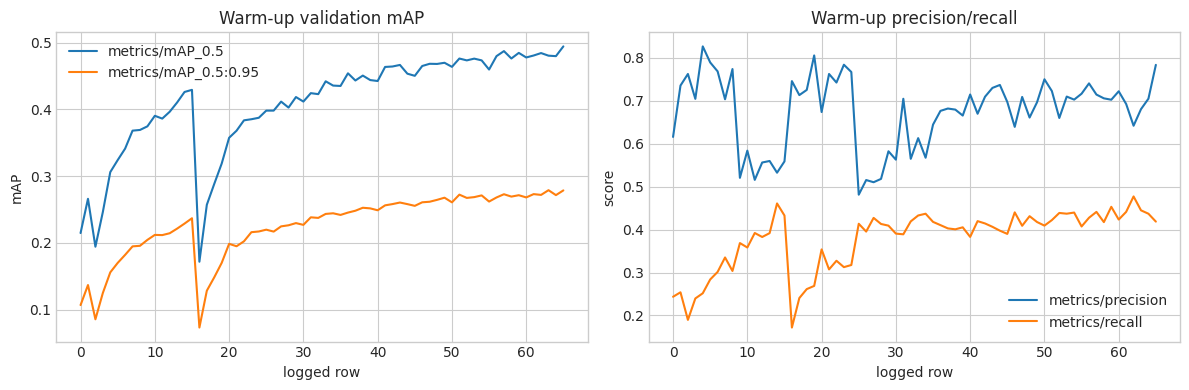

saved table: efficientteacher_fedsto/validation_reports/tables/training_round_metric_aggregate.csv
saved figure: efficientteacher_fedsto/validation_reports/figures/federated_round_accuracy_summary.png


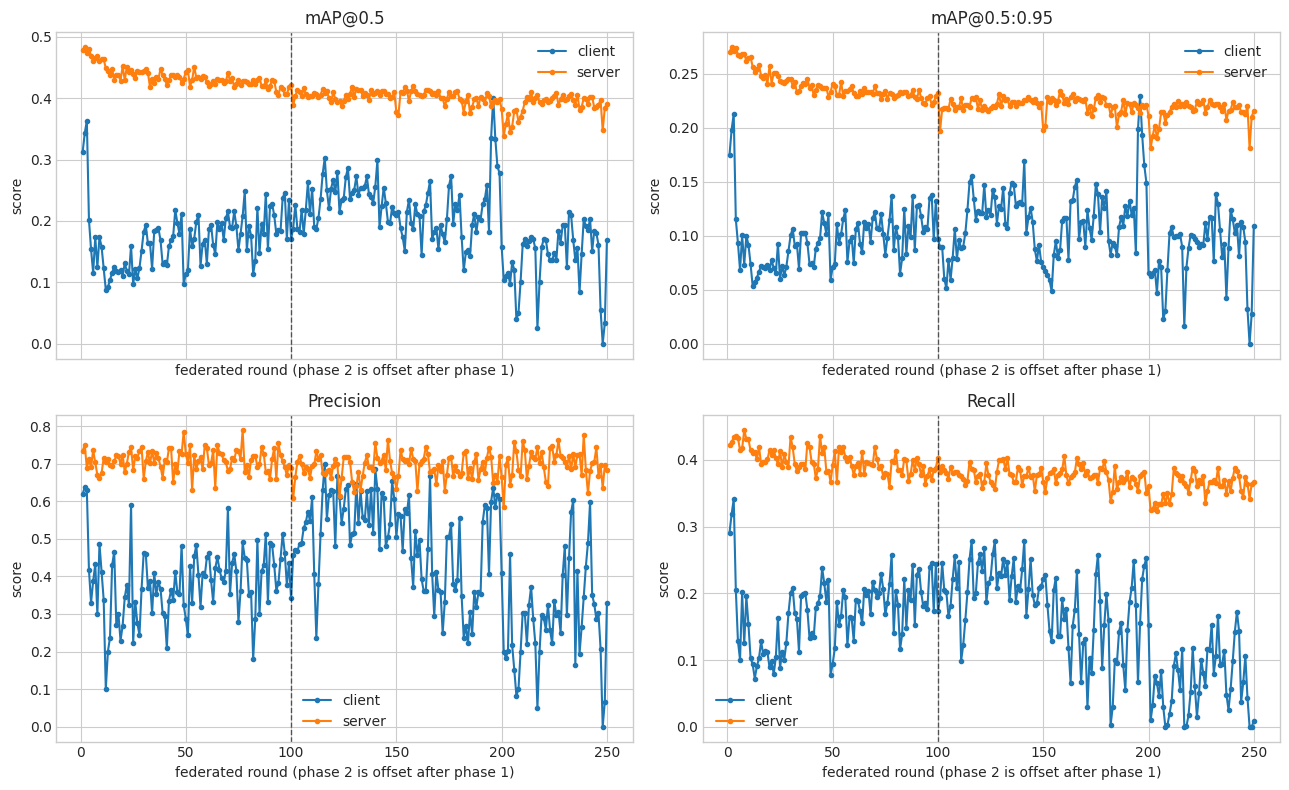

saved figure: efficientteacher_fedsto/validation_reports/figures/server_class_distribution.png


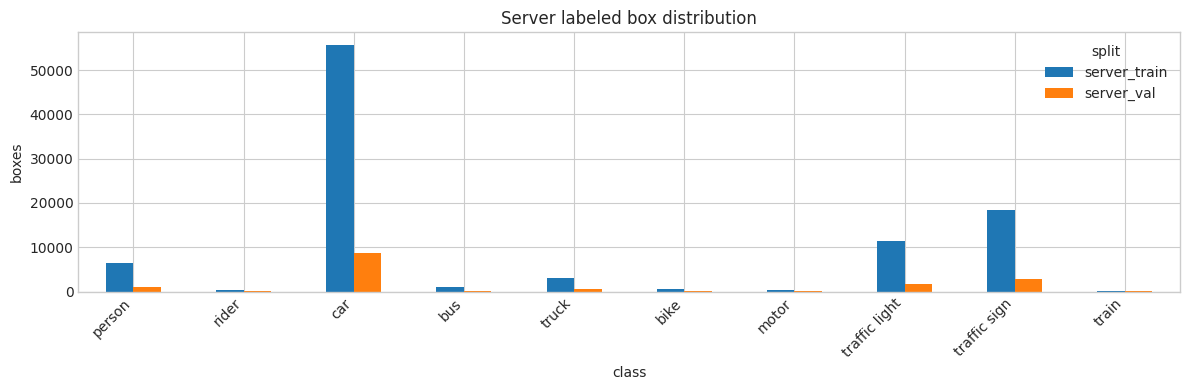

In [13]:
# Accuracy, loss, and class-balance figures for quick paper inspection.

if "all_metrics" not in globals() or all_metrics.empty:
    print("No metrics loaded; run the results ingestion cell first.")
else:
    warmup = all_metrics[all_metrics["role"] == "warmup"].copy()
    if not warmup.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        warmup.plot(x="row_index", y=["metrics/mAP_0.5", "metrics/mAP_0.5:0.95"], ax=axes[0])
        axes[0].set_title("Warm-up validation mAP")
        axes[0].set_xlabel("logged row")
        axes[0].set_ylabel("mAP")
        warmup.plot(x="row_index", y=["metrics/precision", "metrics/recall"], ax=axes[1])
        axes[1].set_title("Warm-up precision/recall")
        axes[1].set_xlabel("logged row")
        axes[1].set_ylabel("score")
        fig.tight_layout()
        fig_path = FIG_ROOT / "warmup_accuracy_curves.png"
        fig.savefig(fig_path, dpi=200)
        print("saved figure:", rel(fig_path))
        plt.show()

    if "run_summary" in globals() and not run_summary.empty:
        round_metrics = run_summary[run_summary["phase"].isin([1, 2])].copy()
        if not round_metrics.empty:
            phase1_rounds = int(ACTIVE_SCHEDULE.get("phase1_rounds", PAPER_SCHEDULE.get("phase1_rounds", 100)))
            round_metrics["federated_round"] = round_metrics["round"].astype(float)
            round_metrics.loc[round_metrics["phase"] == 2, "federated_round"] += phase1_rounds
            aggregate = (
                round_metrics
                .groupby(["phase", "federated_round", "role"], dropna=False)
                .agg(
                    map50_mean=("final_metrics/mAP_0.5", "mean"),
                    map50_std=("final_metrics/mAP_0.5", "std"),
                    map_mean=("final_metrics/mAP_0.5:0.95", "mean"),
                    precision_mean=("final_metrics/precision", "mean"),
                    recall_mean=("final_metrics/recall", "mean"),
                    runs=("run_name", "count"),
                )
                .reset_index()
            )
            save_table(aggregate, "training_round_metric_aggregate.csv")

            fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
            plot_specs = [
                ("map50_mean", "mAP@0.5", axes[0, 0]),
                ("map_mean", "mAP@0.5:0.95", axes[0, 1]),
                ("precision_mean", "Precision", axes[1, 0]),
                ("recall_mean", "Recall", axes[1, 1]),
            ]
            for metric, title, axis in plot_specs:
                for role, group in aggregate.groupby("role"):
                    group = group.sort_values("federated_round")
                    axis.plot(group["federated_round"], group[metric], marker="o", linewidth=1.5, markersize=3, label=role)
                axis.axvline(phase1_rounds, color="black", linestyle="--", linewidth=1, alpha=0.6)
                axis.set_title(title)
                axis.set_xlabel("federated round (phase 2 is offset after phase 1)")
                axis.set_ylabel("score")
                axis.legend()
            fig.tight_layout()
            fig_path = FIG_ROOT / "federated_round_accuracy_summary.png"
            fig.savefig(fig_path, dpi=200)
            print("saved figure:", rel(fig_path))
            plt.show()

    if "class_distribution" in globals() and not class_distribution.empty:
        labeled_classes = class_distribution[class_distribution["split"].isin(["server_train", "server_val"])].copy()
        if not labeled_classes.empty:
            pivot = labeled_classes.pivot_table(index="class_name", columns="split", values="boxes", aggfunc="sum", fill_value=0)
            pivot = pivot.reindex(CLASS_NAMES)
            axis = pivot.plot(kind="bar", figsize=(12, 4))
            axis.set_title("Server labeled box distribution")
            axis.set_xlabel("class")
            axis.set_ylabel("boxes")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            fig_path = FIG_ROOT / "server_class_distribution.png"
            plt.savefig(fig_path, dpi=200)
            print("saved figure:", rel(fig_path))
            plt.show()

In [14]:
# FedSTO protocol and config audit.
# This checks that generated configs match the paper-scale protocol used by the runner.

if yaml is None:
    raise ModuleNotFoundError("PyYAML is required for config audit. Install PyYAML and rerun this cell.")


def load_yaml_config(path: Path) -> dict:
    with path.open(encoding="utf-8") as handle:
        return yaml.safe_load(handle) or {}


def infer_config_role_and_phase(path: Path, cfg: dict) -> tuple[str, int | None]:
    name_blob = " ".join([path.name, str(cfg.get("name", ""))]).lower()
    dataset = cfg.get("Dataset", {}) or {}
    role = "client" if dataset.get("target") else "server"
    if "warmup" in name_blob:
        role = "warmup"
    phase = None
    if "phase1" in name_blob:
        phase = 1
    elif "phase2" in name_blob:
        phase = 2
    return role, phase


config_rows = []
for config_path in sorted((WORK_ROOT / "configs").glob("*.yaml")):
    cfg = load_yaml_config(config_path)
    dataset = cfg.get("Dataset", {}) or {}
    fedsto = cfg.get("FedSTO", {}) or {}
    ssod = cfg.get("SSOD", {}) or {}
    hyp = cfg.get("hyp", {}) or {}
    loss = cfg.get("Loss", {}) or {}
    role, phase = infer_config_role_and_phase(config_path, cfg)
    issues = []

    if dataset.get("nc") != NC:
        issues.append(f"nc={dataset.get('nc')} expected {NC}")
    if list(dataset.get("names", [])) != CLASS_NAMES:
        issues.append("class names differ from manifest")
    if str(dataset.get("train", "")) and not Path(dataset["train"]).exists():
        issues.append("train list missing")
    if str(dataset.get("val", "")) and not Path(dataset["val"]).exists():
        issues.append("val list missing")
    if role == "client" and not dataset.get("target"):
        issues.append("client config has no target list")
    if role == "client" and ssod.get("train_domain") is not True:
        issues.append("client SSOD.train_domain is not True")
    if role in {"server", "warmup"} and ssod.get("train_domain") is not False:
        issues.append("server/warmup SSOD.train_domain is not False")
    if phase == 1 and fedsto.get("train_scope") != "backbone":
        issues.append(f"phase1 train_scope={fedsto.get('train_scope')} expected backbone")
    if phase == 2 and fedsto.get("train_scope") != "all":
        issues.append(f"phase2 train_scope={fedsto.get('train_scope')} expected all")
    if phase == 1 and float(fedsto.get("orthogonal_weight", 0) or 0) != 0:
        issues.append("phase1 orthogonal weight should be 0")
    if phase == 2 and float(fedsto.get("orthogonal_weight", 0) or 0) <= 0:
        issues.append("phase2 orthogonal weight should be positive")
    if role == "client":
        if numeric_or_nan(ssod.get("ignore_thres_low")) != 0.1:
            issues.append("ignore_thres_low differs from 0.1")
        if numeric_or_nan(ssod.get("ignore_thres_high")) != 0.6:
            issues.append("ignore_thres_high differs from 0.6")
        if numeric_or_nan(ssod.get("ema_rate")) != 0.999:
            issues.append("ema_rate differs from 0.999")
    if numeric_or_nan(hyp.get("lr0")) != 0.01:
        issues.append("lr0 differs from 0.01")
    if numeric_or_nan(loss.get("cls")) != 0.3:
        issues.append("classification loss weight differs from 0.3")
    if numeric_or_nan(loss.get("obj")) != 0.7:
        issues.append("objectness loss weight differs from 0.7")
    if numeric_or_nan(loss.get("anchor_t")) != 4.0:
        issues.append("anchor_t differs from 4.0")
    if role == "warmup" and config_path.name == "server_warmup_yolov5l_bdd100k.yaml":
        expected_warmup = int(PAPER_SCHEDULE.get("warmup_epochs", 50))
        if int(dataset.get("batch_size", -1)) <= 0:
            issues.append("batch_size must be positive")
        if int(cfg.get("epochs", -1)) != expected_warmup:
            issues.append(f"base warmup epochs={cfg.get('epochs')} expected {expected_warmup}")

    config_rows.append({
        "config_file": str(config_path),
        "name": cfg.get("name"),
        "role": role,
        "phase": phase,
        "epochs": cfg.get("epochs"),
        "train_scope": fedsto.get("train_scope"),
        "orthogonal_weight": fedsto.get("orthogonal_weight"),
        "orthogonal_scope": fedsto.get("orthogonal_scope"),
        "target_present": bool(dataset.get("target")),
        "ssod_train_domain": ssod.get("train_domain"),
        "ignore_thres_low": ssod.get("ignore_thres_low"),
        "ignore_thres_high": ssod.get("ignore_thres_high"),
        "ema_rate": ssod.get("ema_rate"),
        "lr0": hyp.get("lr0"),
        "loss_cls": loss.get("cls"),
        "loss_obj": loss.get("obj"),
        "anchor_t": loss.get("anchor_t"),
        "status": "OK" if not issues else "CHECK",
        "issues": "; ".join(issues),
    })

config_audit = pd.DataFrame(config_rows)
save_table(config_audit, "fedsto_config_protocol_audit.csv")
display_table(config_audit[["config_file", "name", "role", "phase", "epochs", "train_scope", "orthogonal_weight", "status", "issues"]], rows=80)

saved table: efficientteacher_fedsto/validation_reports/tables/fedsto_config_protocol_audit.csv


,config_file,name,role,phase,epochs,train_scope,orthogonal_weight,status,issues
0,/app/Object_Detection/navigating_data_heteroge...,client_0_overcast_phase1,client,1.0,1,backbone,0.0000,OK,
1,/app/Object_Detection/navigating_data_heteroge...,client_0_overcast_phase2,client,2.0,1,all,0.0001,OK,
2,/app/Object_Detection/navigating_data_heteroge...,client_1_rainy_phase1,client,1.0,1,backbone,0.0000,OK,
3,/app/Object_Detection/navigating_data_heteroge...,client_1_rainy_phase2,client,2.0,1,all,0.0001,OK,
4,/app/Object_Detection/navigating_data_heteroge...,client_2_snowy_phase1,client,1.0,1,backbone,0.0000,OK,
...,...,...,...,...,...,...,...,...,...
75,/app/Object_Detection/navigating_data_heteroge...,phase1_round030_client0_overcast,client,1.0,1,backbone,0.0000,OK,
76,/app/Object_Detection/navigating_data_heteroge...,phase1_round030_client1_rainy,client,1.0,1,backbone,0.0000,OK,
77,/app/Object_Detection/navigating_data_heteroge...,phase1_round030_client2_snowy,client,1.0,1,backbone,0.0000,OK,
78,/app/Object_Detection/navigating_data_heteroge...,phase1_round031_client0_overcast,client,1.0,1,backbone,0.0000,OK,


In [15]:
# Checkpoint, history, and artifact inventory audit.
# Defaults avoid loading large checkpoints. Set LOAD_CHECKPOINTS_FOR_VALIDATION=True for a CPU torch.load smoke test.

LOAD_CHECKPOINTS_FOR_VALIDATION = False


def checkpoint_kind(path: Path) -> str:
    text = str(path)
    if "/global_checkpoints/" in text:
        return "global"
    if "/client_states/" in text:
        return "client_state"
    if "/runs/" in text and "/weights/" in text:
        return "run_weight"
    if "/weights/" in text:
        return "pretrained_or_other_weight"
    return "other"


def checkpoint_record(path: Path) -> dict:
    exists = path.exists()
    stat = path.stat() if exists else None
    parsed = parse_run_metadata(path.parent.parent.name if path.parent.name == "weights" else path.stem)
    return {
        "path": str(path),
        "kind": checkpoint_kind(path),
        "exists": exists,
        "size_mb": round(stat.st_size / (1024 ** 2), 3) if stat else np.nan,
        "modified_utc": datetime.fromtimestamp(stat.st_mtime, timezone.utc).isoformat() if stat else "",
        "phase": parsed.get("phase"),
        "round": parsed.get("round"),
        "role": parsed.get("role"),
        "client_id": parsed.get("client_id"),
    }


checkpoint_paths = []
checkpoint_paths.extend(sorted((WORK_ROOT / "global_checkpoints").glob("*.pt")))
checkpoint_paths.extend(sorted((WORK_ROOT / "client_states").glob("*.pt")))
checkpoint_paths.extend(sorted((WORK_ROOT / "runs").glob("*/weights/*.pt")))
checkpoint_paths.extend(sorted((WORK_ROOT / "weights").glob("*.pt")))
checkpoint_inventory = pd.DataFrame([checkpoint_record(path) for path in checkpoint_paths])
save_table(checkpoint_inventory, "checkpoint_inventory.csv")

history_path = WORK_ROOT / "history.json"
if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
else:
    history = []

history_rows = []
for index, entry in enumerate(history):
    global_path = Path(entry.get("global", ""))
    history_rows.append({
        "history_index": index,
        "phase": entry.get("phase"),
        "round": entry.get("round"),
        "global": str(global_path),
        "global_exists": global_path.exists(),
        "global_size_mb": round(global_path.stat().st_size / (1024 ** 2), 3) if global_path.exists() else np.nan,
    })
history_audit = pd.DataFrame(history_rows)
save_table(history_audit, "history_global_checkpoint_audit.csv")

expected_total_rounds = int(ACTIVE_SCHEDULE.get("phase1_rounds", PAPER_SCHEDULE.get("phase1_rounds", 100))) + int(ACTIVE_SCHEDULE.get("phase2_rounds", PAPER_SCHEDULE.get("phase2_rounds", 150)))
print(f"history rounds completed: {len(history)} / {expected_total_rounds}")
if history:
    print("latest global checkpoint:", history[-1].get("global"))
print("checkpoint inventory by kind")
if checkpoint_inventory.empty:
    print("No checkpoint files found yet.")
else:
    display_table(checkpoint_inventory.groupby("kind", dropna=False).agg(files=("path", "count"), total_size_mb=("size_mb", "sum")).reset_index())

checkpoint_load_rows = []
if LOAD_CHECKPOINTS_FOR_VALIDATION:
    et_root = PROJECT_ROOT / "vendor" / "efficientteacher"
    if str(et_root.resolve()) not in sys.path:
        sys.path.insert(0, str(et_root.resolve()))
    import torch

    candidates = []
    warmup_last = WORK_ROOT / "runs" / "runtime_server_warmup" / "weights" / "last.pt"
    warmup_best = WORK_ROOT / "runs" / "runtime_server_warmup" / "weights" / "best.pt"
    for label, path in (("warmup_last", warmup_last), ("warmup_best", warmup_best)):
        if path.exists():
            candidates.append((label, path))
    if history:
        candidates.append(("latest_global", Path(history[-1]["global"])))

    for label, path in candidates:
        record = {"label": label, "path": str(path), "exists": path.exists(), "load_ok": False, "error": ""}
        try:
            ckpt = torch.load(path, map_location="cpu", weights_only=False)
            record.update({
                "load_ok": isinstance(ckpt, dict),
                "has_model": isinstance(ckpt, dict) and "model" in ckpt,
                "has_ema": isinstance(ckpt, dict) and ckpt.get("ema") is not None,
                "epoch": ckpt.get("epoch") if isinstance(ckpt, dict) else np.nan,
                "best_fitness": ckpt.get("best_fitness") if isinstance(ckpt, dict) else np.nan,
            })
        except Exception as exc:
            record["error"] = repr(exc)
        checkpoint_load_rows.append(record)

checkpoint_load_audit = pd.DataFrame(checkpoint_load_rows)
if not checkpoint_load_audit.empty:
    save_table(checkpoint_load_audit, "checkpoint_load_smoke_test.csv")
    display_table(checkpoint_load_audit)
else:
    print("Checkpoint torch.load smoke test skipped. Set LOAD_CHECKPOINTS_FOR_VALIDATION=True to enable it.")

saved table: efficientteacher_fedsto/validation_reports/tables/checkpoint_inventory.csv
saved table: efficientteacher_fedsto/validation_reports/tables/history_global_checkpoint_audit.csv
history rounds completed: 250 / 250
latest global checkpoint: /app/Object_Detection/navigating_data_heterogeneity/efficientteacher_fedsto/global_checkpoints/phase2_round150_global.pt
checkpoint inventory by kind


,kind,files,total_size_mb
0,client_state,3,274.110
1,global,251,22361.716
2,pretrained_or_other_weight,1,89.177
3,run_weight,1,88.696


Checkpoint torch.load smoke test skipped. Set LOAD_CHECKPOINTS_FOR_VALIDATION=True to enable it.


In [16]:
# Training log triage: failures, NaNs, OOMs, and completed round markers.

log_path = WORK_ROOT / "full_reproduction_latest.log"
flag_patterns = {
    "traceback": re.compile(r"Traceback", re.IGNORECASE),
    "error": re.compile(r"\b(error|exception)\b", re.IGNORECASE),
    "runtime_error": re.compile(r"RuntimeError", re.IGNORECASE),
    "cuda_oom": re.compile(r"out of memory|CUDA error", re.IGNORECASE),
    "nan_or_inf": re.compile(r"\b(nan|inf)\b", re.IGNORECASE),
    "corrupt_data": re.compile(r"corrupt|missing label|image not found", re.IGNORECASE),
    "completed_round": re.compile(r"Completed phase \d+ round \d+", re.IGNORECASE),
}

if not log_path.exists():
    print("No full reproduction log found yet:", log_path)
    log_audit = {}
    flagged_log_lines = []
else:
    lines = log_path.read_text(encoding="utf-8", errors="replace").splitlines()
    flagged_log_lines = []
    counts = {key: 0 for key in flag_patterns}
    for line_number, line in enumerate(lines, start=1):
        for key, pattern in flag_patterns.items():
            if pattern.search(line):
                counts[key] += 1
                if key != "completed_round":
                    flagged_log_lines.append({"line": line_number, "flag": key, "text": line[:500]})
    log_audit = {
        "log_path": str(log_path),
        "lines": len(lines),
        "modified_utc": datetime.fromtimestamp(log_path.stat().st_mtime, timezone.utc).isoformat(),
        **counts,
    }
    (REPORT_ROOT / "log_audit_summary.json").write_text(json.dumps(log_audit, indent=2), encoding="utf-8")
    if flagged_log_lines:
        pd.DataFrame(flagged_log_lines).to_csv(TABLE_ROOT / "training_log_flagged_lines.csv", index=False)
    print(json.dumps(log_audit, indent=2))
    if flagged_log_lines:
        print("Flagged log lines, first 30")
        display_table(pd.DataFrame(flagged_log_lines).head(30), rows=30)
    else:
        print("No failure-like log lines matched the audit patterns.")

{
  "log_path": "/app/Object_Detection/navigating_data_heterogeneity/efficientteacher_fedsto/full_reproduction_latest.log",
  "lines": 862222,
  "modified_utc": "2026-04-23T23:14:34.959417+00:00",
  "traceback": 35,
  "error": 1478,
  "runtime_error": 6,
  "cuda_oom": 0,
  "nan_or_inf": 0,
  "corrupt_data": 9047,
  "completed_round": 250
}
Flagged log lines, first 30


,line,flag,text
0,87,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
1,88,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
2,89,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
3,90,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
4,100,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
5,101,corrupt_data,[34m[1mtrain: [0mScanning '/app/Object_Dete...
6,104,corrupt_data,[34m[1mval: [0mScanning '/app/Object_Detect...
7,24518,traceback,[rank1]: Traceback (most recent call last):
8,24549,traceback,[rank0]: Traceback (most recent call last):
9,24580,traceback,Traceback (most recent call last):


In [17]:
# Optional explicit validation of selected checkpoints with EfficientTeacher val.py.
# Set RUN_EXPLICIT_VAL=True after training to produce final paper-facing mAP logs.

RUN_EXPLICIT_VAL = False
VAL_BATCH_SIZE = 32
VAL_IMGSZ = 640
VAL_DEVICE = ""  # Examples: "0", "0,1", or "cpu". Empty lets EfficientTeacher choose.
VAL_CONF_THRES = 0.001
VAL_IOU_THRES = 0.6


def selected_eval_checkpoints() -> list[tuple[str, Path]]:
    selected = []
    for label, path in [
        ("warmup_best", WORK_ROOT / "runs" / "runtime_server_warmup" / "weights" / "best.pt"),
        ("warmup_last", WORK_ROOT / "runs" / "runtime_server_warmup" / "weights" / "last.pt"),
    ]:
        if path.exists():
            selected.append((label, path))
    if "history" in globals() and history:
        phase1 = [entry for entry in history if int(entry.get("phase", -1)) == 1]
        phase2 = [entry for entry in history if int(entry.get("phase", -1)) == 2]
        if phase1:
            selected.append(("phase1_final_global", Path(phase1[-1]["global"])))
        if phase2:
            selected.append(("phase2_final_global", Path(phase2[-1]["global"])))
        elif history:
            selected.append(("latest_global", Path(history[-1]["global"])))
    deduped = []
    seen = set()
    for label, path in selected:
        key = str(path.resolve())
        if key not in seen:
            deduped.append((label, path))
            seen.add(key)
    return deduped


def parse_val_stdout(stdout: str) -> dict:
    parsed = {}
    for line in stdout.splitlines():
        parts = line.split()
        if len(parts) >= 7 and parts[0] == "all":
            parsed.update({
                "images": numeric_or_nan(parts[1]),
                "labels": numeric_or_nan(parts[2]),
                "precision": numeric_or_nan(parts[3]),
                "recall": numeric_or_nan(parts[4]),
                "map50": numeric_or_nan(parts[5]),
                "map50_95": numeric_or_nan(parts[6]),
            })
    return parsed


explicit_val_rows = []
if RUN_EXPLICIT_VAL:
    et_root = PROJECT_ROOT / "vendor" / "efficientteacher"
    val_cfg = WORK_ROOT / "configs" / "runtime_server_warmup.yaml"
    if not val_cfg.exists():
        val_cfg = WORK_ROOT / "configs" / "server_warmup_yolov5l_bdd100k.yaml"
    selected = selected_eval_checkpoints()
    if not selected:
        print("No checkpoints available for explicit validation yet.")
    for label, weights in selected:
        if not weights.exists():
            explicit_val_rows.append({"label": label, "weights": str(weights), "returncode": np.nan, "error": "missing checkpoint"})
            continue
        safe_label = re.sub(r"[^A-Za-z0-9_.-]+", "_", label)
        cmd = [
            sys.executable, "val.py",
            "--weights", str(weights.resolve()),
            "--cfg", str(val_cfg.resolve()),
            "--batch-size", str(VAL_BATCH_SIZE),
            "--imgsz", str(VAL_IMGSZ),
            "--conf-thres", str(VAL_CONF_THRES),
            "--iou-thres", str(VAL_IOU_THRES),
            "--project", str((REPORT_ROOT / "explicit_val_runs").resolve()),
            "--name", safe_label,
            "--exist-ok",
            "--verbose",
        ]
        if VAL_DEVICE:
            cmd.extend(["--device", VAL_DEVICE])
        print("Running:", " ".join(cmd))
        result = subprocess.run(cmd, cwd=et_root, capture_output=True, text=True)
        log_file = REPORT_ROOT / f"explicit_val_{safe_label}.log"
        log_file.write_text(result.stdout + "\nSTDERR\n" + result.stderr, encoding="utf-8")
        record = {"label": label, "weights": str(weights), "returncode": result.returncode, "log_file": str(log_file)}
        record.update(parse_val_stdout(result.stdout))
        if result.returncode != 0:
            record["error"] = result.stderr[-1000:]
        explicit_val_rows.append(record)

explicit_val_summary = pd.DataFrame(explicit_val_rows)
if not explicit_val_summary.empty:
    save_table(explicit_val_summary, "explicit_checkpoint_validation_summary.csv")
    display_table(explicit_val_summary)
else:
    print("Explicit checkpoint validation skipped. Set RUN_EXPLICIT_VAL=True after the run finishes.")
    print("Candidate checkpoints:")
    for label, path in selected_eval_checkpoints():
        print(f"  {label}: {path} exists={path.exists()}")

Explicit checkpoint validation skipped. Set RUN_EXPLICIT_VAL=True after the run finishes.
Candidate checkpoints:
  warmup_last: /app/Object_Detection/navigating_data_heterogeneity/efficientteacher_fedsto/runs/runtime_server_warmup/weights/last.pt exists=True
  phase1_final_global: /app/Object_Detection/navigating_data_heterogeneity/efficientteacher_fedsto/global_checkpoints/phase1_round100_global.pt exists=True
  phase2_final_global: /app/Object_Detection/navigating_data_heterogeneity/efficientteacher_fedsto/global_checkpoints/phase2_round150_global.pt exists=True


In [18]:
# Build a compact validation manifest for paper writing and reproducibility.

publication_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "work_root": str(WORK_ROOT),
    "report_root": str(REPORT_ROOT),
    "paper_schedule": PAPER_SCHEDULE,
    "active_schedule": ACTIVE_SCHEDULE,
    "classes": CLASS_NAMES,
    "artifacts": {
        "tables": sorted(rel(path) for path in TABLE_ROOT.glob("*.csv")),
        "figures": sorted(rel(path) for path in FIG_ROOT.glob("*.png")),
        "logs": sorted(rel(path) for path in REPORT_ROOT.glob("*.log")),
    },
}

if "split_audit" in globals() and not split_audit.empty:
    publication_manifest["dataset"] = {
        "splits": split_audit[["split", "listed_images", "existing_images", "missing_images", "missing_labels", "boxes", "label_errors"]].to_dict(orient="records"),
        "total_listed_images": int(split_audit["listed_images"].sum()),
        "total_label_errors": int(split_audit["label_errors"].sum()),
    }
if "run_summary" in globals() and not run_summary.empty:
    metric_cols = [column for column in ["final_metrics/mAP_0.5", "final_metrics/mAP_0.5:0.95", "final_metrics/precision", "final_metrics/recall"] if column in run_summary.columns]
    publication_manifest["accuracy"] = {
        "runs_with_metrics": int(len(run_summary)),
        "best_by_map50_95": run_summary.sort_values("best_metrics/mAP_0.5:0.95", ascending=False).head(10).to_dict(orient="records") if "best_metrics/mAP_0.5:0.95" in run_summary else [],
        "metric_columns": metric_cols,
    }
if "round_coverage" in globals() and not round_coverage.empty:
    publication_manifest["round_coverage"] = {
        "rounds_with_any_output": int(len(round_coverage)),
        "complete_round_outputs": int(round_coverage["complete_round_outputs"].sum()),
    }
if "config_audit" in globals() and not config_audit.empty:
    publication_manifest["config_audit"] = {
        "configs_checked": int(len(config_audit)),
        "configs_with_issues": int((config_audit["status"] != "OK").sum()),
    }
if "history" in globals():
    publication_manifest["history"] = {
        "completed_rounds": int(len(history)),
        "expected_rounds": int(ACTIVE_SCHEDULE.get("phase1_rounds", PAPER_SCHEDULE.get("phase1_rounds", 100))) + int(ACTIVE_SCHEDULE.get("phase2_rounds", PAPER_SCHEDULE.get("phase2_rounds", 150))),
        "latest_global": history[-1].get("global") if history else None,
    }

manifest_out = REPORT_ROOT / "paper_validation_manifest.json"
manifest_out.write_text(json.dumps(publication_manifest, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

md_lines = [
    "# FedSTO Validation Summary",
    "",
    f"Created UTC: {publication_manifest['created_utc']}",
    f"Report root: `{rel(REPORT_ROOT)}`",
    "",
    "## Artifacts",
    f"- Tables: {len(publication_manifest['artifacts']['tables'])}",
    f"- Figures: {len(publication_manifest['artifacts']['figures'])}",
    f"- Logs: {len(publication_manifest['artifacts']['logs'])}",
    "",
]
if "dataset" in publication_manifest:
    md_lines.extend([
        "## Dataset",
        f"- Total listed images across all lists: {publication_manifest['dataset']['total_listed_images']}",
        f"- Total label errors: {publication_manifest['dataset']['total_label_errors']}",
        "",
    ])
if "history" in publication_manifest:
    md_lines.extend([
        "## Training Progress",
        f"- Completed rounds: {publication_manifest['history']['completed_rounds']} / {publication_manifest['history']['expected_rounds']}",
        f"- Latest global checkpoint: `{publication_manifest['history']['latest_global']}`",
        "",
    ])
if "accuracy" in publication_manifest:
    md_lines.extend([
        "## Accuracy Evidence",
        f"- Runs with EfficientTeacher metrics: {publication_manifest['accuracy']['runs_with_metrics']}",
        f"- Metric columns: {', '.join(publication_manifest['accuracy']['metric_columns'])}",
        "",
    ])
if "config_audit" in publication_manifest:
    md_lines.extend([
        "## Config Audit",
        f"- Configs checked: {publication_manifest['config_audit']['configs_checked']}",
        f"- Configs with issues: {publication_manifest['config_audit']['configs_with_issues']}",
        "",
    ])

summary_md = REPORT_ROOT / "paper_validation_summary.md"
summary_md.write_text("\n".join(md_lines), encoding="utf-8")

print("saved:", rel(manifest_out))
print("saved:", rel(summary_md))
print("Validation suite complete. Use the CSV tables and PNG figures in", rel(REPORT_ROOT))

saved: efficientteacher_fedsto/validation_reports/paper_validation_manifest.json
saved: efficientteacher_fedsto/validation_reports/paper_validation_summary.md
Validation suite complete. Use the CSV tables and PNG figures in efficientteacher_fedsto/validation_reports
